## 1. Imports, paths, configuration

# Learned BEM Residual / DLA - LOSO 5/10/15 -> 22

Deep Learning Approach (DLA) ported into a notebook: the existing `DLAModel` (MLP K -> M with optional channel-space ResNet refiner) and `dla_total_loss` from [scripts/phase3_residual_hybrid/dla/](../../../scripts/phase3_residual_hybrid/dla/), inlined here. 

BCI IV-2a evaluation matches `eval_bci_iv2a.py`: reconstruction-only training (`lambda_fwd=0`) with dummy lead-field buffers, group-aware standard scaling, and early stopping on validation reconstruction loss.

The model retains its **learnable conductivity blend** (`tanh` of three free parameters) for compatibility with the original DLA architecture; the forward-consistency loss is disabled in this BCI IV-2a benchmark to match the existing evaluation.

In [11]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from tqdm.auto import tqdm

import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

METHOD_NAME = 'learned_bem_residual'
METHOD_TITLE = 'Learned_BEM_Residual'
ARCHITECTURE = 'mlp_resnet19'
SFREQ = 250
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42

MAX_EPOCHS = 50
PATIENCE = 8
BATCH_SIZE = 512
LR = 1e-3
WEIGHT_DECAY = 1e-5
VAL_FRAC = 0.1
MAX_TRAIN_SAMPLES = 200000
MAX_TEST_SAMPLES = 0
MAX_SPLITS = 0

DEFAULT_FORWARD_RIDGE = 1e-3
DEFAULT_CONDUCTIVITY_BLEND_MAX = 0.25
REFINE_HIDDEN = 64
REFINE_BLOCKS = 3
MLP_HIDDEN = 128
LAMBDA_FWD = 0.0

torch.manual_seed(SEED)
np.random.seed(SEED)

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != 'new_repository' and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if REPO_ROOT.name != 'new_repository':
    raise RuntimeError('Run from inside new_repository tree.')

PROCESSED_DIR = REPO_ROOT / 'Processed_BCI_Competition_Data'
RESULTS_DIR = REPO_ROOT / 'Results' / METHOD_TITLE
VIZ_DIR = REPO_ROOT / 'Results_Visualization' / METHOD_TITLE
CKPT_DIR = REPO_ROOT / 'Model_Files' / 'Checkpoints' / METHOD_TITLE
SCALER_DIR = REPO_ROOT / 'Model_Files' / 'Scalers' / METHOD_TITLE
PLOT_DIR = REPO_ROOT / 'Model_Files' / 'TrainingPlots' / METHOD_TITLE
for d in (RESULTS_DIR, VIZ_DIR, CKPT_DIR, SCALER_DIR, PLOT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print('PROCESSED_DIR =', PROCESSED_DIR)
print('DEVICE        =', DEVICE)
print('ARCHITECTURE  =', ARCHITECTURE)

PROCESSED_DIR = C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Processed_BCI_Competition_Data
DEVICE        = cuda
ARCHITECTURE  = mlp_resnet19


## 2. Channel sets, data loaders, metrics

In [12]:
CHANNELS_22 = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4',
    'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz',
]
CHANNEL_SET_5 = ['Fz', 'C3', 'C4', 'Pz', 'POz']
CHANNEL_SET_10 = ['Fz', 'FC3', 'FC4', 'C3', 'Cz', 'C4', 'CP3', 'CP4', 'Pz', 'POz']
CHANNEL_SET_15 = ['Fz', 'FC3', 'FC1', 'FC2', 'FC4', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP3', 'CP1', 'CP2', 'CP4', 'Pz']
CHANNEL_SETS = [CHANNEL_SET_5, CHANNEL_SET_10, CHANNEL_SET_15]

CHANNEL_POS_2D = {
    'Fz': (0.00, 0.62), 'FC3': (-0.33, 0.34), 'FC1': (-0.14, 0.34), 'FCz': (0.00, 0.32),
    'FC2': (0.14, 0.34), 'FC4': (0.33, 0.34), 'C5': (-0.50, 0.00), 'C3': (-0.33, 0.00),
    'C1': (-0.14, 0.00), 'Cz': (0.00, 0.00), 'C2': (0.14, 0.00), 'C4': (0.33, 0.00),
    'C6': (0.50, 0.00), 'CP3': (-0.33, -0.30), 'CP1': (-0.14, -0.30), 'CPz': (0.00, -0.30),
    'CP2': (0.14, -0.30), 'CP4': (0.33, -0.30), 'P1': (-0.14, -0.52), 'Pz': (0.00, -0.54),
    'P2': (0.14, -0.52), 'POz': (0.00, -0.82),
}


def load_subject_data(subject_dir: Path):
    npz = np.load(subject_dir / 'trials.npz', allow_pickle=True)
    return npz['X'].astype(np.float32), npz['y'].astype(np.int32)


def to_sample_matrix(trials_ch_time):
    n_trials, n_channels, n_times = trials_ch_time.shape
    return np.transpose(trials_ch_time, (0, 2, 1)).reshape(n_trials * n_times, n_channels)


def compute_metrics(y_true, y_pred):
    diff = y_true - y_pred
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mae = float(np.mean(np.abs(diff)))
    yt = y_true.reshape(-1)
    yp = y_pred.reshape(-1)
    yt_c = yt - yt.mean()
    yp_c = yp - yp.mean()
    den = np.sqrt(np.sum(yt_c ** 2) * np.sum(yp_c ** 2))
    pearson_r = float(np.sum(yt_c * yp_c) / den) if den > 0 else float('nan')
    ss_res = float(np.sum((yt - yp) ** 2))
    ss_tot = float(np.sum((yt - yt.mean()) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
    return {'rmse': rmse, 'mae': mae, 'pearson_r': pearson_r, 'r2': r2}


def _band_power(psd, freqs, lo, hi):
    mask = (freqs >= lo) & (freqs < hi)
    if not np.any(mask):
        return np.zeros(psd.shape[0])
    return np.trapezoid(psd[:, mask], freqs[mask], axis=1)


def compute_band_metrics(y_true, y_pred, sfreq=SFREQ):
    nperseg = min(512, y_true.shape[0])
    freqs, psd_t = welch(y_true.T, fs=sfreq, nperseg=nperseg, axis=1)
    _, psd_p = welch(y_pred.T, fs=sfreq, nperseg=nperseg, axis=1)
    bands = {
        'delta': (0.5, 4.0), 'theta': (4.0, 8.0), 'alpha': (8.0, 13.0),
        'beta': (13.0, 30.0), 'gamma': (30.0, 45.0),
    }
    out = {}
    for name, (lo, hi) in bands.items():
        bt = _band_power(psd_t, freqs, lo, hi)
        bp = _band_power(psd_p, freqs, lo, hi)
        out[f'band_rmse_{name}'] = float(np.sqrt(np.mean((bt - bp) ** 2)))
    return out


loso_splits = json.loads((PROCESSED_DIR / 'loso_splits.json').read_text(encoding='utf-8'))
if MAX_SPLITS > 0:
    loso_splits = loso_splits[:MAX_SPLITS]
print(f'Loaded {len(loso_splits)} LOSO splits.')

Loaded 9 LOSO splits.


## 3. DLA model + losses (inlined from `scripts/phase3_residual_hybrid/dla/`)

In [13]:
ARCHITECTURES = ('mlp', 'mlp_resnet19')


class ScalpResNet(nn.Module):
    def __init__(self, dim, hidden=64, n_blocks=3):
        super().__init__()
        if dim < 2:
            raise ValueError('ScalpResNet requires dim >= 2.')
        self.blocks = nn.ModuleList()
        for _ in range(n_blocks):
            self.blocks.append(nn.Sequential(
                nn.Linear(dim, hidden),
                nn.ReLU(inplace=True),
                nn.Linear(hidden, dim),
            ))

    def forward(self, y):
        for blk in self.blocks:
            y = y + blk(y)
        return y


class DLAModel(nn.Module):
    """K observed channels -> M missing channels via MLP, optional ScalpResNet refiner.
    Lead-field blend tensor `G_eff = G0 + sum_i w_i * dG_i` is preserved for compatibility,
    but `forward_consistent_scalp` is only invoked when `lambda_fwd > 0`.
    """
    def __init__(self, n_input, n_output, G0, dG, architecture='mlp',
                 refine_hidden=REFINE_HIDDEN, refine_blocks=REFINE_BLOCKS,
                 forward_ridge=DEFAULT_FORWARD_RIDGE, blend_max=DEFAULT_CONDUCTIVITY_BLEND_MAX,
                 hidden=MLP_HIDDEN):
        super().__init__()
        if architecture not in ARCHITECTURES:
            raise ValueError(f'architecture must be one of {ARCHITECTURES}, got {architecture!r}')
        if n_output < 2:
            raise ValueError('DLAModel expects n_output >= 2.')
        if G0.ndim != 2 or dG.ndim != 3 or dG.shape[0] != 3:
            raise ValueError('Expected G0 (n_ch, n_src) and dG (3, n_ch, n_src)')
        if G0.shape[0] != n_output or dG.shape[1] != n_output:
            raise ValueError('G0/dG channel dimension must match n_output.')
        self.architecture = architecture
        self.register_buffer('G0', G0)
        self.register_buffer('dG', dG)
        self.forward_ridge = float(forward_ridge)
        self.blend_max = float(blend_max)
        self.conductivity_raw = nn.Parameter(torch.zeros(3))
        self.net = nn.Sequential(
            nn.Linear(n_input, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, n_output),
        )
        if architecture == 'mlp_resnet19':
            self.scalp_refine = ScalpResNet(dim=n_output, hidden=refine_hidden, n_blocks=refine_blocks)
        else:
            self.scalp_refine = nn.Identity()

    def blend_weights(self):
        return self.blend_max * torch.tanh(self.conductivity_raw)

    def effective_gain(self):
        w = self.blend_weights().view(3, 1, 1)
        return self.G0 + (w * self.dG).sum(dim=0)

    def forward(self, x):
        y = self.net(x)
        y = self.scalp_refine(y)
        return y

    def forward_consistent_scalp(self, y_pred):
        G = self.effective_gain()
        n_ch = G.shape[0]
        ggt = G @ G.T + self.forward_ridge * torch.eye(n_ch, device=G.device, dtype=G.dtype)
        alpha = torch.linalg.solve(ggt, y_pred.T)
        j = G.T @ alpha
        return (G @ j).T


def reconstruction_loss(y_pred, y_true):
    return nn.functional.mse_loss(y_pred, y_true)


def forward_consistency_loss(model, y_pred):
    y_phys = model.forward_consistent_scalp(y_pred)
    return nn.functional.mse_loss(y_phys, y_pred)


def dla_total_loss(model, y_pred, y_true, lambda_fwd):
    l_rec = reconstruction_loss(y_pred, y_true)
    if lambda_fwd and float(lambda_fwd) > 0.0:
        l_fwd = forward_consistency_loss(model, y_pred)
    else:
        l_fwd = torch.zeros((), dtype=l_rec.dtype, device=l_rec.device)
    total = l_rec + float(lambda_fwd) * l_fwd
    parts = {
        'loss': float(total.detach()),
        'loss_rec': float(l_rec.detach()),
        'loss_fwd': float(l_fwd.detach()),
    }
    return total, parts


def _dummy_gain(n_output, device):
    g0 = torch.zeros((n_output, 1), dtype=torch.float32, device=device)
    dg = torch.zeros((3, n_output, 1), dtype=torch.float32, device=device)
    return g0, dg

## 4. Trainer with early stopping (matches `eval_bci_iv2a.py`)

In [14]:
def train_dla(x_train, y_train, x_val, y_val,
              architecture=ARCHITECTURE, device=DEVICE, seed=SEED,
              lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE,
              max_epochs=MAX_EPOCHS, patience=PATIENCE, lambda_fwd=LAMBDA_FWD):
    torch.manual_seed(seed)
    np.random.seed(seed)
    n_in = int(x_train.shape[1])
    n_out = int(y_train.shape[1])
    G0, dG = _dummy_gain(n_out, device)
    model = DLAModel(
        n_input=n_in, n_output=n_out, G0=G0, dG=dG, architecture=architecture,
    ).to(device)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    X_tr_t = torch.tensor(x_train, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    X_va_t = torch.tensor(x_val, dtype=torch.float32, device=device)
    y_va_t = torch.tensor(y_val, dtype=torch.float32, device=device)
    n = X_tr_t.shape[0]
    history = {'train_loss': [], 'val_loss': [], 'val_rec': [], 'val_fwd': []}
    best = float('inf')
    best_state = None
    wait = 0
    pbar = tqdm(range(max_epochs), desc='epoch', leave=False, unit='ep')
    for _epoch in pbar:
        perm = torch.randperm(n, device=device)
        losses = []
        model.train(True)
        for start in range(0, n, batch_size):
            idx = perm[start: start + batch_size]
            xb = X_tr_t[idx]
            yb = y_tr_t[idx]
            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss, parts = dla_total_loss(model, pred, yb, lambda_fwd=lambda_fwd)
            loss.backward()
            opt.step()
            losses.append(float(parts['loss']))
        model.train(False)
        with torch.no_grad():
            pred_va = model(X_va_t)
            _l_va, parts_va = dla_total_loss(model, pred_va, y_va_t, lambda_fwd=lambda_fwd)
        history['train_loss'].append(float(np.mean(losses)) if losses else float('nan'))
        history['val_loss'].append(float(parts_va['loss']))
        history['val_rec'].append(float(parts_va['loss_rec']))
        history['val_fwd'].append(float(parts_va['loss_fwd']))
        monitored = float(parts_va['loss_rec'])
        pbar.set_postfix(train=f'{history["train_loss"][-1]:.5f}', val_rec=f'{monitored:.5f}', wait=wait)
        if monitored < best:
            best = monitored
            wait = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def predict_dla(model, x):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(x, dtype=torch.float32, device=DEVICE)).cpu().numpy()

## 5. LOSO sweep with tqdm

In [15]:
rows = []
rng = np.random.default_rng(SEED)
viz_payloads = {}  # Store payloads for all channel sets

outer = tqdm(loso_splits, desc='LOSO splits', unit='split')
for split in outer:
    test_subject = split['test_subject']
    train_subjects = split['train_subjects']
    outer.set_postfix(test=test_subject)
    
    # Load test data
    x_test_trials, _ = load_subject_data(PROCESSED_DIR / test_subject)
    n_trials, _, n_times = x_test_trials.shape
    test_samples_full = to_sample_matrix(x_test_trials)
    if MAX_TEST_SAMPLES > 0 and test_samples_full.shape[0] > MAX_TEST_SAMPLES:
        test_samples = test_samples_full[rng.choice(test_samples_full.shape[0], size=MAX_TEST_SAMPLES, replace=False)]
    else:
        test_samples = test_samples_full
    
    for ch_set in tqdm(CHANNEL_SETS, desc=f'{test_subject} channels', leave=False, unit='set'):
        n_in = len(ch_set)
        input_idx = [CHANNELS_22.index(c) for c in ch_set]
        missing = [c for c in CHANNELS_22 if c not in ch_set]
        miss_idx = [CHANNELS_22.index(c) for c in missing]
        
        stem = f'{METHOD_NAME}_{n_in}ch_{test_subject}'
        model_path = CKPT_DIR / f'{stem}.pt'
        scaler_path = SCALER_DIR / f'{stem}_scaler.joblib'
        
        # ========== ROBUST MODEL/SCALER LOADING/CREATION ==========
        model_exists = model_path.exists() and scaler_path.exists()
        
        if model_exists:
            # LOAD existing pretrained model and scaler
            n_out = len(missing)
            G0, dG = _dummy_gain(n_out, DEVICE)
            model = DLAModel(
                n_input=n_in, n_output=n_out, G0=G0, dG=dG, architecture=ARCHITECTURE,
            ).to(DEVICE)
            state = torch.load(model_path, map_location=DEVICE)
            model.load_state_dict(state)
            scaler = joblib.load(scaler_path)
            # print(f'  ✓ Loaded existing: {stem}')
        else:
            # TRAIN new model and create scaler
            # Load training data
            train_blocks = [to_sample_matrix(load_subject_data(PROCESSED_DIR / s)[0]) for s in train_subjects]
            train_samples = np.concatenate(train_blocks, axis=0)
            if MAX_TRAIN_SAMPLES > 0 and train_samples.shape[0] > MAX_TRAIN_SAMPLES:
                train_samples = train_samples[rng.choice(train_samples.shape[0], size=MAX_TRAIN_SAMPLES, replace=False)]
            
            # Prepare data
            X_in = train_samples[:, input_idx]
            Y_miss = train_samples[:, miss_idx]
            n_total = X_in.shape[0]
            n_val = max(1, int(round(VAL_FRAC * n_total)))
            perm = rng.permutation(n_total)
            va = perm[:n_val]
            tr = perm[n_val:]
            
            # Create and fit scaler
            scaler = StandardScaler().fit(X_in[tr])
            x_tr = scaler.transform(X_in[tr]).astype(np.float32)
            x_va = scaler.transform(X_in[va]).astype(np.float32)
            y_tr = Y_miss[tr].astype(np.float32)
            y_va = Y_miss[va].astype(np.float32)
            
            # Train model
            model, history = train_dla(x_tr, y_tr, x_va, y_va)
            
            # Save model and scaler
            torch.save(model.state_dict(), model_path)
            joblib.dump(scaler, scaler_path)
            
            # Save training loss plot
            fig_loss, ax = plt.subplots(figsize=(6, 3.5))
            ax.plot(history['train_loss'], label='train', color='tab:blue')
            ax.plot(history['val_rec'], label='val (rec)', color='tab:orange')
            ax.set_xlabel('epoch')
            ax.set_ylabel('reconstruction MSE')
            ax.set_title(f'{METHOD_TITLE} ({ARCHITECTURE}) - {n_in}ch -> 22 - {test_subject}')
            ax.legend()
            ax.grid(True, alpha=0.3)
            fig_loss.tight_layout()
            fig_loss.savefig(PLOT_DIR / f'{stem}_loss.png', dpi=120)
            plt.close(fig_loss)
            # print(f'  ✓ Trained and saved: {stem}')
        
        # ========== MAKE PREDICTIONS WITH LOADED/TRAINED MODEL ==========
        x_test_obs = scaler.transform(test_samples[:, input_idx]).astype(np.float32)
        y_test_miss = test_samples[:, miss_idx]
        y_pred = predict_dla(model, x_test_obs)
        
        # Compute overall metrics
        m = compute_metrics(y_test_miss, y_pred)
        m.update(compute_band_metrics(y_test_miss, y_pred))
        
        # Compute per-channel metrics
        diff_per_ch = y_test_miss - y_pred
        rmse_per_ch = np.sqrt(np.mean(diff_per_ch ** 2, axis=0))
        mae_per_ch = np.mean(np.abs(diff_per_ch), axis=0)
        
        # Correlation per channel
        r_per_ch = []
        r2_per_ch = []
        for ch_idx in range(len(missing)):
            yt = y_test_miss[:, ch_idx]
            yp = y_pred[:, ch_idx]
            yt_c = yt - yt.mean()
            yp_c = yp - yp.mean()
            den = np.sqrt(np.sum(yt_c ** 2) * np.sum(yp_c ** 2))
            r = float(np.sum(yt_c * yp_c) / den) if den > 0 else float('nan')
            r_per_ch.append(r)
            
            ss_res = np.sum((yt - yp) ** 2)
            ss_tot = np.sum((yt - yt.mean()) ** 2)
            r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
            r2_per_ch.append(r2)
        
        # Build base row with metadata
        base_row = {
            'test_subject': test_subject,
            'n_input_channels': n_in,
            'input_channels': ','.join(ch_set),
            'n_reconstructed_channels': len(missing),
            'method': METHOD_TITLE,
            'n_test_trials': int(n_trials),
            'n_test_samples': int(test_samples.shape[0]),
            'model_loaded': bool(model_exists),  # Track if model was loaded vs trained
            **m,  # Overall metrics
        }
        
        # Append overall metrics row
        rows.append(base_row)
        
        # Append per-channel rows
        for ch_idx, ch_name in enumerate(missing):
            ch_row = base_row.copy()
            ch_row.update({
                'channel': ch_name,
                'rmse': float(rmse_per_ch[ch_idx]),
                'mae': float(mae_per_ch[ch_idx]),
                'pearson_r': float(r_per_ch[ch_idx]),
                'r2': float(r2_per_ch[ch_idx]),
            })
            rows.append(ch_row)
        
        # Store visualization payload for all channel sets
        x_full_trial = x_test_trials[0]
        samples_trial = to_sample_matrix(x_full_trial[None, :, :])
        x_in_trial = scaler.transform(samples_trial[:, input_idx]).astype(np.float32)
        y_true_trial = samples_trial[:, miss_idx]
        y_pred_trial = predict_dla(model, x_in_trial)
        viz_payloads[n_in] = {
            'test_subject': test_subject,
            'input_channels': list(ch_set),
            'missing_channels': list(missing),
            'y_true_trial': y_true_trial,
            'y_pred_trial': y_pred_trial,
            'n_times': int(x_full_trial.shape[1]),
            'Y_true_all': y_test_miss,
            'Y_pred_all': y_pred,
        }

metrics_df = pd.DataFrame(rows)
print(f'✓ Created {len(metrics_df)} rows (overall + per-channel)')
print(f'  Models trained: {(~metrics_df["model_loaded"]).sum() // len(CHANNEL_SETS)}')
print(f'  Models loaded:  {metrics_df["model_loaded"].sum() // len(CHANNEL_SETS)}')
metrics_df.head(20)

LOSO splits: 100%|██████████| 9/9 [00:26<00:00,  2.97s/split, test=A09T]

✓ Created 351 rows (overall + per-channel)
  Models trained: 0
  Models loaded:  117


,test_subject,n_input_channels,input_channels,n_reconstructed_channels,method,n_test_trials,n_test_samples,model_loaded,rmse,mae,pearson_r,r2,band_rmse_delta,band_rmse_theta,band_rmse_alpha,band_rmse_beta,band_rmse_gamma,channel
0,A01T,5,"Fz,C3,C4,Pz,POz",17,Learned_BEM_Residual,273,273000,True,2.271522,1.752273,0.974298,0.949072,2.793217,1.800616,1.435253,1.132657,0.557358,NaN
1,A01T,5,"Fz,C3,C4,Pz,POz",17,Learned_BEM_Residual,273,273000,True,2.118204,1.678211,0.977820,0.954818,2.793217,1.800616,1.435253,1.132657,0.557358,FC3
2,A01T,5,"Fz,C3,C4,Pz,POz",17,Learned_BEM_Residual,273,273000,True,2.247405,1.765884,0.978019,0.956132,2.793217,1.800616,1.435253,1.132657,0.557358,FC1
3,A01T,5,"Fz,C3,C4,Pz,POz",17,Learned_BEM_Residual,273,273000,True,2.893644,2.265075,0.966686,0.933780,2.793217,1.800616,1.435253,1.132657,0.557358,FCz
4,A01T,5,"Fz,C3,C4,Pz,POz",17,Learned_BEM_Residual,273,273000,True,2.066810,1.618438,0.981979,0.963366,2.793217,1.800616,1.435253,1.132657,0.557358,FC2
5,A01T,5,"Fz,C3,C4,Pz,POz",17,Learned_BEM_Residual,273,273000,True,2.211465,1.744611,0.977255,0.954336,2.793217,1.800616,1.435253,1.132657,0.557358,FC4
6,A01T,5,"Fz,C3,C4,Pz,POz",17,Learned_BEM_Residual,273,273000,True,3.017469,2.405294,0.928780,0.861849,2.793217,1.800616,1.435253,1.132657,0.557358,C5
7,A01T,5,"Fz,C3,C4,Pz,POz",17,Learned_BEM_Residual,273,273000,True,2.120011,1.683540,0.978882,0.957695,2.793217,1.800616,1.435253,1.132657,0.557358,C1
8,A01T,5,"Fz,C3,C4,Pz,POz",17,Learned_BEM_Residual,273,273000,True,2.872786,2.271565,0.966173,0.932064,2.793217,1.800616,1.435253,1.132657,0.557358,Cz
9,A01T,5,"Fz,C3,C4,Pz,POz",17,Learned_BEM_Residual,273,273000,True,2.033116,1.613086,0.981474,0.962416,2.793217,1.800616,1.435253,1.132657,0.557358,C2


## 6. Save metrics CSV and summary JSON

In [16]:
csv_path = RESULTS_DIR / f'{METHOD_NAME}_loso_metrics_all.csv'
json_path = RESULTS_DIR / f'{METHOD_NAME}_summary_all.json'
metrics_df.to_csv(csv_path, index=False)

# Create summaries for overall results (rows without 'channel' column)
overall_df = metrics_df[metrics_df['channel'].isna()].copy() if 'channel' in metrics_df.columns else metrics_df
per_ch_df = metrics_df[~metrics_df['channel'].isna()].copy() if 'channel' in metrics_df.columns else pd.DataFrame()

metric_cols = ['rmse', 'mae', 'pearson_r', 'r2',
               'band_rmse_delta', 'band_rmse_theta', 'band_rmse_alpha',
               'band_rmse_beta', 'band_rmse_gamma']

# Summary by input channel count (overall metrics)
summary_by_channels = (
    overall_df.groupby('n_input_channels', as_index=False)[metric_cols]
    .agg(['mean', 'std'])
)
summary_by_channels.columns = [
    c if isinstance(c, str) else (c[0] if c[1] == '' else f'{c[0]}_{c[1]}')
    for c in summary_by_channels.columns
]
summary_by_channels = summary_by_channels.reset_index(drop=True)

# Per-channel summary (if available)
per_channel_summary = None
if not per_ch_df.empty:
    per_channel_summary = (
        per_ch_df.groupby(['n_input_channels', 'channel'], as_index=False)[['rmse', 'mae', 'pearson_r', 'r2']]
        .agg(['mean', 'std'])
    )
    per_channel_summary.columns = [
        c if isinstance(c, str) else (c[0] if c[1] == '' else f'{c[0]}_{c[1]}')
        for c in per_channel_summary.columns
    ]
    per_channel_summary = per_channel_summary.reset_index(drop=True)

summary_dict = {
    'method': METHOD_NAME,
    'architecture': ARCHITECTURE,
    'total_rows': int(len(metrics_df)),
    'overall_rows': int(len(overall_df)),
    'per_channel_rows': int(len(per_ch_df)),
    'splits': int(len(loso_splits)),
    'device': str(DEVICE),
    'lambda_fwd': LAMBDA_FWD,
    'lr': LR,
    'weight_decay': WEIGHT_DECAY,
    'batch_size': BATCH_SIZE,
    'max_epochs': MAX_EPOCHS,
    'patience': PATIENCE,
    'channel_sets': {'5': CHANNEL_SET_5, '10': CHANNEL_SET_10, '15': CHANNEL_SET_15},
    'mean_metrics_by_channel_count': summary_by_channels.to_dict(orient='records'),
}

if per_channel_summary is not None:
    summary_dict['per_channel_metrics_mean'] = per_channel_summary.to_dict(orient='records')

json_path.write_text(json.dumps(summary_dict, indent=2), encoding='utf-8')

print('✓ Saved metrics CSV    :', csv_path)
print('✓ Saved summary JSON   :', json_path)
print(f'  - Overall metrics from {len(overall_df)} rows')
print(f'  - Per-channel metrics from {len(per_ch_df)} rows')
print(f'\n📊 Models created/loaded:')
if 'model_loaded' in metrics_df.columns:
    n_trained = (~overall_df['model_loaded']).sum()
    n_loaded = overall_df['model_loaded'].sum()
    print(f'  - New models trained: {n_trained}')
    print(f'  - Pretrained models used: {n_loaded}')

✓ Saved metrics CSV    : C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results\Learned_BEM_Residual\learned_bem_residual_loso_metrics_all.csv
✓ Saved summary JSON   : C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results\Learned_BEM_Residual\learned_bem_residual_summary_all.json
  - Overall metrics from 27 rows
  - Per-channel metrics from 324 rows

📊 Models created/loaded:
  - New models trained: 0
  - Pretrained models used: 27


## 7. Visualization

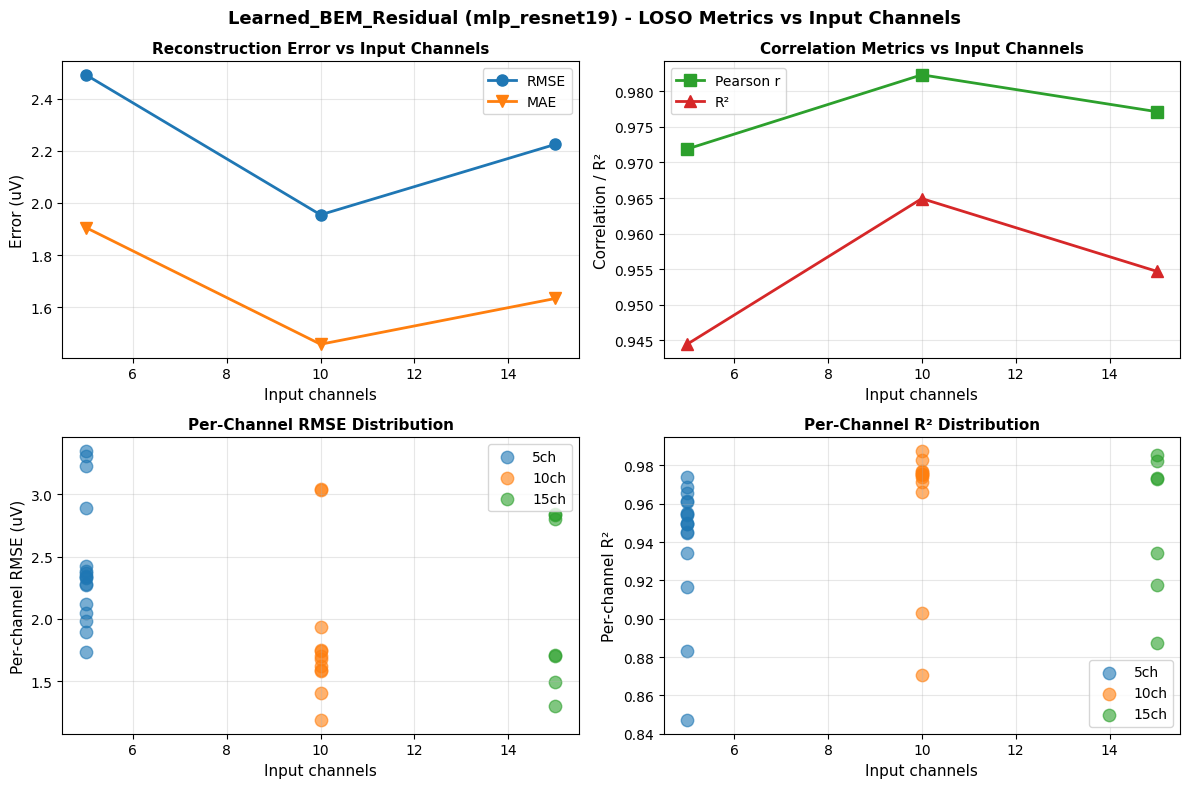

✓ Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Learned_BEM_Residual\learned_bem_residual_metrics_vs_channels.png


In [17]:
# Plot metrics vs number of input channels (overall and per-channel)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Filter overall metrics (without 'channel' column)
overall_df_plot = metrics_df[metrics_df['channel'].isna()].copy() if 'channel' in metrics_df.columns else metrics_df
agg = overall_df_plot.groupby('n_input_channels', as_index=False)[['rmse', 'mae', 'pearson_r', 'r2']].mean()

# Plot 1: Error metrics (RMSE, MAE)
ax = axes[0, 0]
ax.plot(agg['n_input_channels'], agg['rmse'], marker='o', linewidth=2, markersize=8, color='tab:blue', label='RMSE')
ax.plot(agg['n_input_channels'], agg['mae'], marker='v', linewidth=2, markersize=8, color='tab:orange', label='MAE')
ax.set_xlabel('Input channels', fontsize=11)
ax.set_ylabel('Error (uV)', fontsize=11)
ax.set_title('Reconstruction Error vs Input Channels', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Correlation metrics (Pearson r, R²)
ax = axes[0, 1]
ax.plot(agg['n_input_channels'], agg['pearson_r'], marker='s', linewidth=2, markersize=8, color='tab:green', label='Pearson r')
ax.plot(agg['n_input_channels'], agg['r2'], marker='^', linewidth=2, markersize=8, color='tab:red', label='R²')
ax.set_xlabel('Input channels', fontsize=11)
ax.set_ylabel('Correlation / R²', fontsize=11)
ax.set_title('Correlation Metrics vs Input Channels', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Per-channel RMSE distribution
if 'channel' in metrics_df.columns and not per_ch_df.empty:
    ax = axes[1, 0]
    for n_ch in [5, 10, 15]:
        ch_data = per_ch_df[per_ch_df['n_input_channels'] == n_ch]
        if not ch_data.empty:
            rmse_vals = ch_data.groupby('channel')['rmse'].mean()
            ax.scatter([n_ch]*len(rmse_vals), rmse_vals, s=80, alpha=0.6, label=f'{n_ch}ch')
    ax.set_xlabel('Input channels', fontsize=11)
    ax.set_ylabel('Per-channel RMSE (uV)', fontsize=11)
    ax.set_title('Per-Channel RMSE Distribution', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
else:
    axes[1, 0].text(0.5, 0.5, 'No per-channel data', ha='center', va='center')

# Plot 4: Per-channel R² distribution
if 'channel' in metrics_df.columns and not per_ch_df.empty:
    ax = axes[1, 1]
    for n_ch in [5, 10, 15]:
        ch_data = per_ch_df[per_ch_df['n_input_channels'] == n_ch]
        if not ch_data.empty:
            r2_vals = ch_data.groupby('channel')['r2'].mean()
            ax.scatter([n_ch]*len(r2_vals), r2_vals, s=80, alpha=0.6, label=f'{n_ch}ch')
    ax.set_xlabel('Input channels', fontsize=11)
    ax.set_ylabel('Per-channel R²', fontsize=11)
    ax.set_title('Per-Channel R² Distribution', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
else:
    axes[1, 1].text(0.5, 0.5, 'No per-channel data', ha='center', va='center')

fig.suptitle(f'{METHOD_TITLE} ({ARCHITECTURE}) - LOSO Metrics vs Input Channels', fontsize=13, fontweight='bold')
fig.tight_layout()
out_p = VIZ_DIR / f'{METHOD_NAME}_metrics_vs_channels.png'
fig.savefig(out_p, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {out_p}')

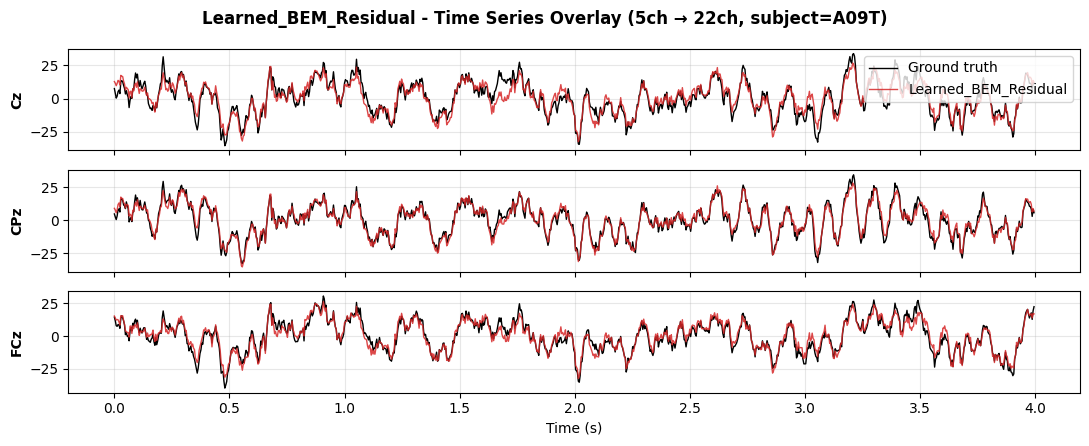

✓ Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Learned_BEM_Residual\learned_bem_residual_5ch_timeseries_overlay.png


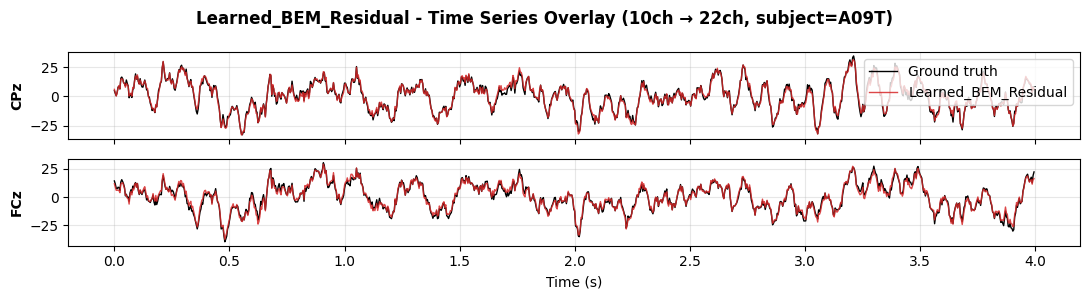

✓ Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Learned_BEM_Residual\learned_bem_residual_10ch_timeseries_overlay.png


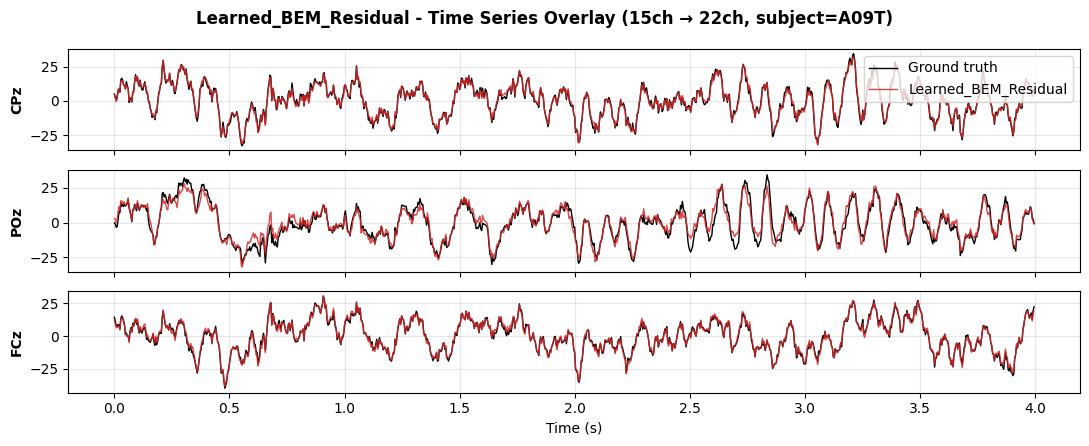

✓ Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Learned_BEM_Residual\learned_bem_residual_15ch_timeseries_overlay.png


In [18]:
# Time series overlay for all channel sets
for n_in in [5, 10, 15]:
    if n_in not in viz_payloads:
        continue
    
    viz_payload = viz_payloads[n_in]
    n_times = viz_payload['n_times']
    miss = viz_payload['missing_channels']
    yt = viz_payload['y_true_trial']
    yp = viz_payload['y_pred_trial']
    
    # Show central channels if available, otherwise first 6
    central_channels = ['Cz', 'C3', 'CPz', 'Pz', 'C4', 'POz', 'FCz', 'Fz']
    show_channels = [c for c in central_channels if c in miss][:6]
    if not show_channels:
        show_channels = miss[:6]
    
    times = np.arange(n_times) / SFREQ
    fig, axes = plt.subplots(len(show_channels), 1, figsize=(11, 1.5 * len(show_channels)), sharex=True)
    if len(show_channels) == 1:
        axes = [axes]
    
    for ax, ch in zip(axes, show_channels):
        idx = miss.index(ch)
        ax.plot(times, yt[:, idx], color='black', linewidth=1.0, label='Ground truth')
        ax.plot(times, yp[:, idx], color='tab:red', linewidth=1.0, alpha=0.85, label=METHOD_TITLE)
        ax.set_ylabel(ch, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    axes[0].legend(loc='upper right', fontsize=10)
    axes[-1].set_xlabel('Time (s)', fontsize=10)
    fig.suptitle(f'{METHOD_TITLE} - Time Series Overlay ({n_in}ch → 22ch, subject={viz_payload["test_subject"]})', 
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    out_p = VIZ_DIR / f'{METHOD_NAME}_{n_in}ch_timeseries_overlay.png'
    fig.savefig(out_p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved: {out_p}')

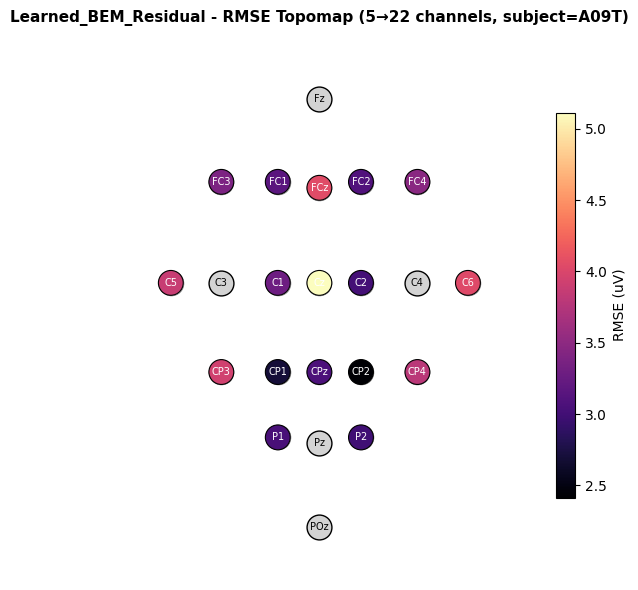

✓ Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Learned_BEM_Residual\learned_bem_residual_5ch_rmse_topomap.png


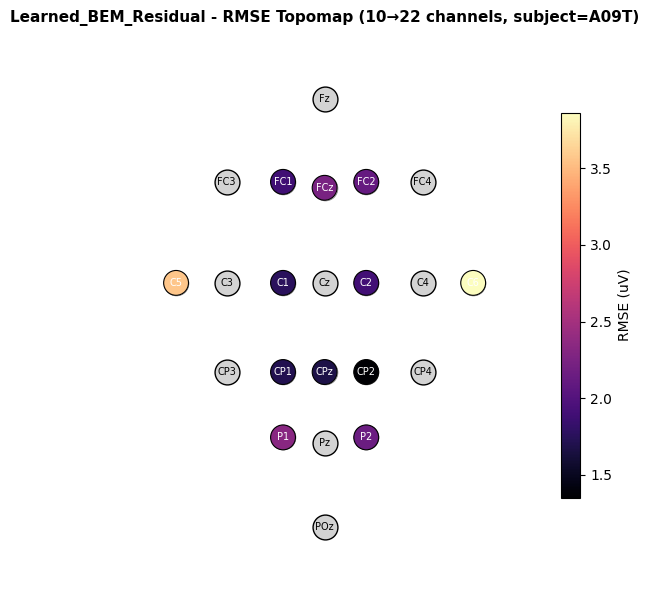

✓ Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Learned_BEM_Residual\learned_bem_residual_10ch_rmse_topomap.png


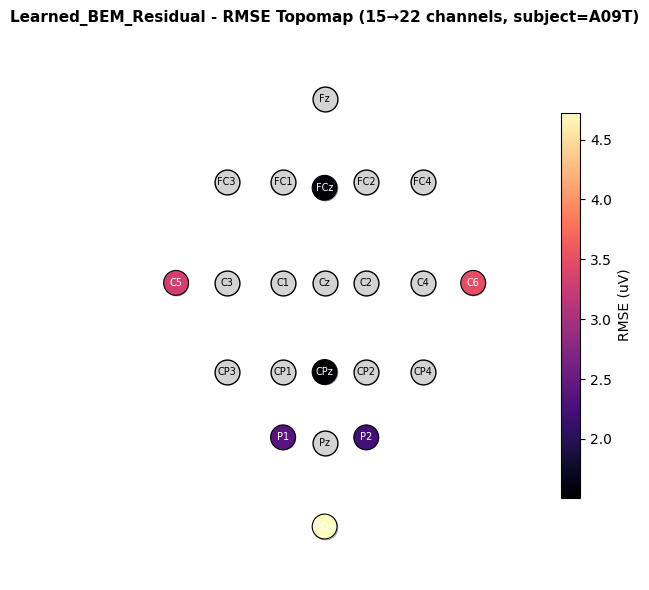

✓ Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Learned_BEM_Residual\learned_bem_residual_15ch_rmse_topomap.png


In [19]:
# Create RMSE topmaps for all channel sets
for n_in in sorted(viz_payloads.keys()):
    viz_payload = viz_payloads[n_in]
    Y_true = viz_payload['Y_true_all']
    Y_pred = viz_payload['Y_pred_all']
    miss = viz_payload['missing_channels']
    inp = viz_payload['input_channels']
    
    rmse_per_ch = np.sqrt(np.mean((Y_true - Y_pred) ** 2, axis=0))
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Draw input channels (light gray)
    for ch in CHANNELS_22:
        x, y = CHANNEL_POS_2D[ch]
        if ch in inp:
            ax.scatter(x, y, c='lightgray', s=320, edgecolors='k', linewidths=1.0, zorder=2)
            ax.text(x, y, ch, ha='center', va='center', fontsize=7, zorder=3)
        else:
            ax.scatter(x, y, c='white', s=320, edgecolors='gray', linewidths=0.5, zorder=2)
    
    # Draw reconstructed channels with RMSE heatmap
    sc = ax.scatter(
        [CHANNEL_POS_2D[c][0] for c in miss],
        [CHANNEL_POS_2D[c][1] for c in miss],
        c=rmse_per_ch, cmap='magma', s=320, edgecolors='k', linewidths=0.8, zorder=4,
    )
    
    # Add channel labels
    for ch in miss:
        x, y = CHANNEL_POS_2D[ch]
        ax.text(x, y, ch, ha='center', va='center', fontsize=7, color='white', zorder=5)
    
    cbar = plt.colorbar(sc, ax=ax, shrink=0.7, label='RMSE (uV)')
    ax.set_xlim(-0.7, 0.7)
    ax.set_ylim(-1.0, 0.85)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'{METHOD_TITLE} - RMSE Topomap ({n_in}→22 channels, subject={viz_payload["test_subject"]})', 
                 fontsize=11, fontweight='bold')
    
    fig.tight_layout()
    out_p = VIZ_DIR / f'{METHOD_NAME}_{n_in}ch_rmse_topomap.png'
    fig.savefig(out_p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved: {out_p}')

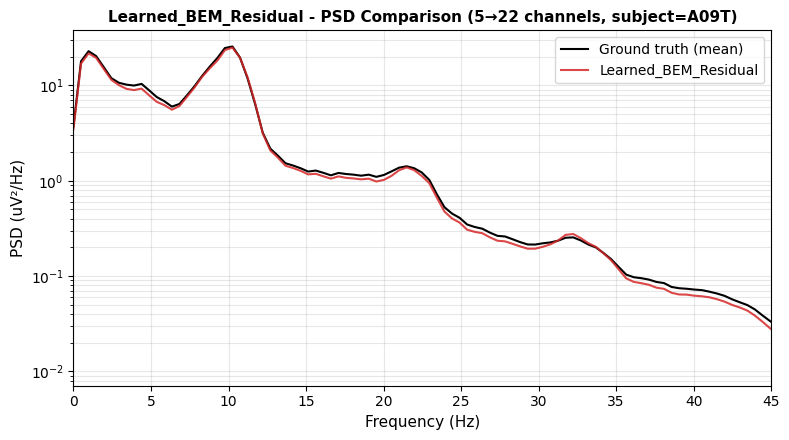

✓ Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Learned_BEM_Residual\learned_bem_residual_5ch_psd_comparison.png


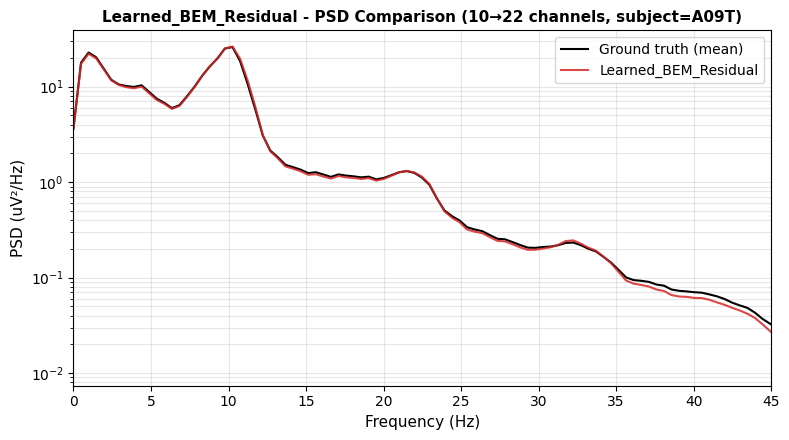

✓ Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Learned_BEM_Residual\learned_bem_residual_10ch_psd_comparison.png


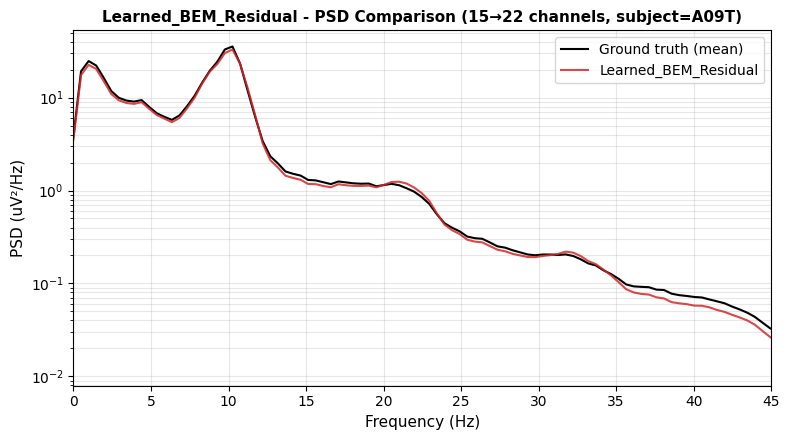

✓ Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Learned_BEM_Residual\learned_bem_residual_15ch_psd_comparison.png


In [20]:
# Create PSD comparisons for all channel sets
for n_in in sorted(viz_payloads.keys()):
    viz_payload = viz_payloads[n_in]
    Y_true = viz_payload['Y_true_all']
    Y_pred = viz_payload['Y_pred_all']
    
    nperseg = min(512, Y_true.shape[0])
    freqs, psd_t = welch(Y_true.T, fs=SFREQ, nperseg=nperseg, axis=1)
    _, psd_p = welch(Y_pred.T, fs=SFREQ, nperseg=nperseg, axis=1)
    
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.semilogy(freqs, psd_t.mean(axis=0), color='black', linewidth=1.5, label='Ground truth (mean)')
    ax.semilogy(freqs, psd_p.mean(axis=0), color='tab:red', linewidth=1.5, alpha=0.85, label=METHOD_TITLE)
    ax.set_xlim(0, 45)
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel('PSD (uV²/Hz)', fontsize=11)
    ax.set_title(f'{METHOD_TITLE} - PSD Comparison ({n_in}→22 channels, subject={viz_payload["test_subject"]})', 
                 fontsize=11, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=10)
    
    fig.tight_layout()
    out_p = VIZ_DIR / f'{METHOD_NAME}_{n_in}ch_psd_comparison.png'
    fig.savefig(out_p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved: {out_p}')